In [1]:
import gymnasium as gym

## Training an Agent with Q-learning
instead of let the agent choose random actions each round, let's develop a policy (mapping states in action, optimizing the long term reward)

### The Learning Process
Try an action and see what happens (reward + new state)

Update your cheat sheet: “That action was better/worse than I thought”

Gradually improve by trying actions and updating estimates

Balance exploration vs exploitation: Try new things vs use what you know works

### Blackjack environment:
Clear rules: Get closer to 21 than the dealer without going over

Simple observations: Your hand value, dealer’s showing card, usable ace

Discrete actions: Hit (take card) or Stand (keep current hand)

Immediate feedback: Win, lose, or draw after each hand



In [2]:
from collections import defaultdict
import numpy as np

In [3]:
class BlackjackAgent:
    def __init__(
            self,
            env: gym.Env,
            learning_rate: float,
            initial_epsilon: float,
            epsilon_decay:float,
            final_epsilon: float,
            discount_factor: float = 0.95,
    ):
        self.env = env

        # Q-table: maps (state, action) to expected reward
        # defaultdict automatically creates entries with zeros for new states
        self.q_values = defaultdict(lambda: np.zeros(env.action_space.n))

        self.lr = learning_rate
        self.discount_factor = discount_factor
        self.epsilon = initial_epsilon
        self.epsilon_decay = epsilon_decay
        self.final_epsilon = final_epsilon

        # Track learning progress
        self.training_error = []

    def get_action(self, obs: tuple[int, int, bool]) -> int:
        # return an action using the epsilon-greedy strategy
        if np.random.random()< self.epsilon:
            return self.env.action_space.sample()
        else:
            return int(np.argmax(self.q_values[obs]))
        
    def update(
        self,
        obs: tuple[int, int, bool],
        action: int,
        reward: float,
        terminated: bool,
        next_obs: tuple[int, int, bool],
    ):
        """Update Q-value based on experience.

        This is the heart of Q-learning: learn from (state, action, reward, next_state)
        """
        # What's the best we could do from the next state?
        # (Zero if episode terminated - no future rewards possible)
        future_q_value = (not terminated) * np.max(self.q_values[next_obs])

        # What should the Q-value be? (Bellman equation)
        target = reward + self.discount_factor * future_q_value

        # How wrong was our current estimate?
        temporal_difference = target - self.q_values[obs][action]

        # Update our estimate in the direction of the error
        # Learning rate controls how big steps we take
        self.q_values[obs][action] = (
            self.q_values[obs][action] + self.lr * temporal_difference
        )

        # Track learning progress (useful for debugging)
        self.training_error.append(temporal_difference)

    def decay_epsilon(self):
        """Reduce exploration rate after each episode."""
        self.epsilon = max(self.final_epsilon, self.epsilon - self.epsilon_decay)


## Training the agent:
1. reset the env
2. play one episode
3. update exploration rate
4. repeat for many episodes untile the agent learns a good strategy

the learning_rate is how we want to consider the new values
the epsilon is how much we want to be explorative (and not greedy)

### Bellman equation for the Q-tables:

 Q(s,a) <- Q(s,a) + lr * [r(s,a) + discount_factor * max_Q(s',a) - Q(s,a)]
 
 Q(s,a) <- (1-lr) * Q(s,a) + lr * [r(s,a) + discount_factor * max_Q(s',a)]

In [4]:
learning_rate = 0.01
n_episodes = 100000
start_epsilon = 1.0
epsilon_decay = start_epsilon / (n_episodes / 2)
final_epsilon = 0.01

# creation of the environment
env = gym.make("Blackjack-v1", sab=False)
env = gym.wrappers.RecordEpisodeStatistics(env, buffer_length=n_episodes)

agent = BlackjackAgent(
    env = env,
    learning_rate=learning_rate,
    initial_epsilon=start_epsilon,
    epsilon_decay=epsilon_decay,
    final_epsilon=final_epsilon,
)

The training Loop

In [7]:
from tqdm import tqdm

for episode in tqdm(range(n_episodes)):
    # start a new hand
    obs, info = env.reset()
    done = False

    #Play a complete episode
    while not done:
        action = agent.get_action(obs) #follows the eps-greedy action selection strategy
        next_obs, reward, terminated, truncated, info = env.step(action)
        # nb: the observation are in this implementation like the state of the agent, he observe its state   

        agent.update(obs, action, reward, terminated, next_obs) #agent learn from the results of the environment
        obs = next_obs 
        done = terminated or truncated
        # the episode is done whenever the agent arrives in a terminal state of the environment 
        # or if he performs actions for too much time and reached a time limit (it is referred to a counter of the environment that is incremented every call till the limit)
    agent.decay_epsilon()

100%|██████████| 100000/100000 [00:17<00:00, 5789.41it/s]


# Analyzing training results

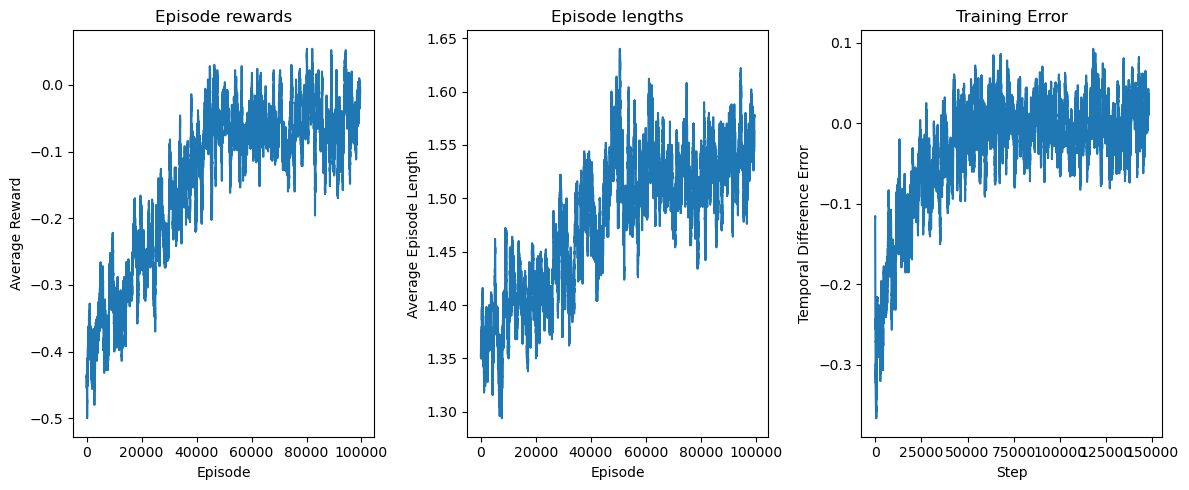

In [8]:
from matplotlib import pyplot as plt

def get_moving_avgs(arr, window, convolution_mode):
    """Compute moving average to smooth noisy data."""
    return np.convolve(
        np.array(arr).flatten(),
        np.ones(window),
        mode=convolution_mode
    ) / window

# Smooth over a 500-episode window
rolling_length = 500
fig, axs = plt.subplots(ncols=3, figsize=(12, 5))

# Episode rewards (win/loss performance)
axs[0].set_title("Episode rewards")
reward_moving_average = get_moving_avgs(
    env.return_queue,
    rolling_length,
    "valid"
)
axs[0].plot(range(len(reward_moving_average)), reward_moving_average)
axs[0].set_ylabel("Average Reward")
axs[0].set_xlabel("Episode")

# Episode lengths (how many actions per hand)
axs[1].set_title("Episode lengths")
length_moving_average = get_moving_avgs(
    env.length_queue,
    rolling_length,
    "valid"
)
axs[1].plot(range(len(length_moving_average)), length_moving_average)
axs[1].set_ylabel("Average Episode Length")
axs[1].set_xlabel("Episode")

# Training error (how much we're still learning)
axs[2].set_title("Training Error")
training_error_moving_average = get_moving_avgs(
    agent.training_error,
    rolling_length,
    "same"
)
axs[2].plot(range(len(training_error_moving_average)), training_error_moving_average)
axs[2].set_ylabel("Temporal Difference Error")
axs[2].set_xlabel("Step")

plt.tight_layout()
plt.show()

reward plot shows the gradual improvment (nb. Blackjack is where even the perfect agent has loss a bit to the house)

episode length shows how many actions the agent tends to do as the episodes increase, higher values means the agent tends to use action "hit" (receive a new card)

training error shows that the going on with the episodes the agents updates became small


## Testing the agent:

In [9]:
# Test the trained agent
def test_agent(agent, env, num_episodes=1000):
    """Test agent performance without learning or exploration."""
    total_rewards = []

    # Temporarily disable exploration for testing
    old_epsilon = agent.epsilon
    agent.epsilon = 0.0  # Pure exploitation

    for _ in range(num_episodes): #number of episodes = game the agent plays
        obs, info = env.reset()
        episode_reward = 0
        done = False

        while not done:  # run an episode
            action = agent.get_action(obs)
            obs, reward, terminated, truncated, info = env.step(action)
            episode_reward += reward
            done = terminated or truncated

        total_rewards.append(episode_reward)

    # Restore original epsilon
    agent.epsilon = old_epsilon

    win_rate = np.mean(np.array(total_rewards) > 0)
    average_reward = np.mean(total_rewards)

    print(f"Test Results over {num_episodes} episodes:")
    print(f"Win Rate: {win_rate:.1%}")
    print(f"Average Reward: {average_reward:.3f}")
    print(f"Standard Deviation: {np.std(total_rewards):.3f}")

# Test your agent
test_agent(agent, env)

Test Results over 1000 episodes:
Win Rate: 43.1%
Average Reward: -0.035
Standard Deviation: 0.946
